<a href="https://colab.research.google.com/github/shahbaz11-arch/NNDDE/blob/main/Problem_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Discovered Probabilistic Hermite Weights (Minimum Norm) ---
w0: 1.648672
w1: -1.648562
w2: 0.824093
w3: -0.274525
w4: 0.068495
w5: -0.013634
w6: 0.002241
w7: -0.000311
w8: 0.000036
w9: -0.000004
w10: 0.000000
w11: -0.000000

--- Solution Evaluation (10 Test Points) ---
x     | y_approx     | y_exact (e^-x)  | Relative Error 
-------------------------------------------------------
0.000 | 1.000000     | 1.000000        | 4.4409e-16     
0.100 | 0.904837     | 0.904837        | 7.1165e-15     
0.200 | 0.818731     | 0.818731        | 1.0577e-14     
0.300 | 0.740818     | 0.740818        | 1.3038e-14     
0.400 | 0.670320     | 0.670320        | 1.4741e-14     
0.500 | 0.606531     | 0.606531        | 1.7206e-14     
0.600 | 0.548812     | 0.548812        | 1.8611e-14     
0.700 | 0.496585     | 0.496585        | 1.9115e-14     
0.800 | 0.449329     | 0.449329        | 1.9767e-14     
0.900 | 0.406570     | 0.406570        | 2.3484e-14     
1.000 | 0.367879     | 0.367879        | 1.

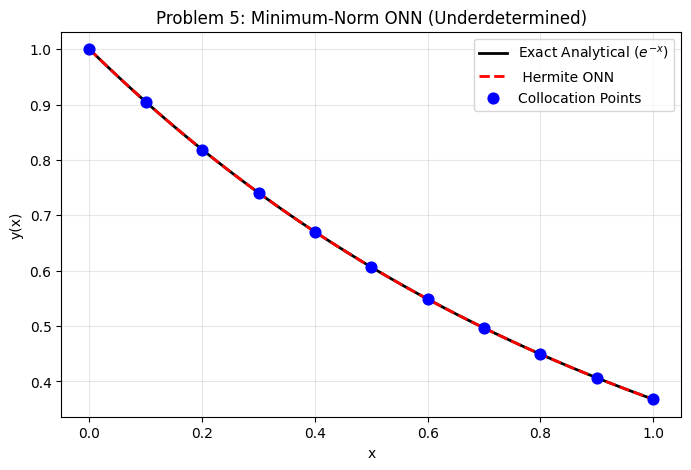

In [1]:
#Problem--5(Hermite)(Verified)
import torch
import matplotlib.pyplot as plt

# ==========================================
# 1.  Hermite Basis Implementation
# ==========================================
def get_prob_hermite_basis(x, n_polys):
    """
    Generates Probabilistic Hermite polynomials He_n(x) and their derivatives He'_n(x)
    using standard recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    He = torch.zeros(num_points, n_polys, dtype=torch.float64)
    He_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> He_0 = 1, He'_0 = 0
    He[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> He_1 = x, He'_1 = 1
        He[:, 1] = x
        He_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
        He[:, n] = x * He[:, n-1] - (n - 1.0) * He[:, n-2]
        He_d[:, n] = float(n) * He[:, n-1]

    return He, He_d

# ==========================================
# 2. Problem Setup (Problem 5 Linear NDDE)
# ==========================================
N_POLYS = 12
points_colloc = torch.linspace(0,1,11,  dtype=torch.float64)

# Initialize Underdetermined System (3 equations, 4 unknowns)
num_equations = len(points_colloc) + 1
A = torch.zeros(num_equations, N_POLYS, dtype=torch.float64)
b = torch.zeros(num_equations, 1, dtype=torch.float64)

# --- Row 0: Initial Condition y(0) = 1 ---
He_0, _ = get_prob_hermite_basis(torch.tensor([0.0], dtype=torch.float64), N_POLYS)
A[0, :] = He_0
b[0, 0] = 1.0

# --- Rows 1-2: ODE Constraints at Collocation Points ---
for i, x_val in enumerate(points_colloc):
    x = torch.tensor([x_val], dtype=torch.float64)

    # 1. Compute delayed argument
    delay_x = 0.50 * x

    # 2. Evaluate basis at current and delayed arguments
    He_x, Hed_x = get_prob_hermite_basis(x, N_POLYS)
    He_delay, Hed_delay = get_prob_hermite_basis(delay_x, N_POLYS)

    # 3. Construct LHS (Coefficients for w_n)
    # Re-arranged NDDE: y'(x) - 0.50y'(0.50x) - 0.50y(0.50x) + y(x) = 0
    coeffs = Hed_x - 0.50 * Hed_delay - 0.50 * He_delay + He_x
    A[i+1, :] = coeffs

    # 4. Construct RHS
    # The right hand side of the equation is exactly 0
    rhs = 0.0
    b[i+1, 0] = rhs

# ==========================================
# 3. Solve for Weights (Least Squares / Pseudoinverse)
# ==========================================
# We use torch.linalg.lstsq because the 3x4 matrix is underdetermined

solution = torch.linalg.lstsq(A, b)
weights = solution.solution

print("--- Discovered Probabilistic Hermite Weights (Minimum Norm) ---")
for i in range(N_POLYS):
    print(f"w{i}: {weights[i].item():.6f}")

# ==========================================
# 4. Evaluate Solution and Relative Error
# ==========================================
print("\n--- Solution Evaluation (10 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (e^-x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 11, dtype=torch.float64)
He_eval, _ = get_prob_hermite_basis(x_eval, N_POLYS)

# Calculate approximate and exact solutions
y_approx = (He_eval @ weights).flatten()
y_exact = torch.exp(-x_eval)

rel_errors = torch.abs(y_approx - y_exact) / torch.abs(y_exact)

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    error_val = rel_errors[i].item()

    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {error_val:<15.4e}")

  # ==========================================
# Calculate and Print Maximum Errors
# ==========================================

# 1. Calculate Maximum Absolute Error
abs_errors = torch.abs(y_approx - y_exact)
max_abs_err = torch.max(abs_errors).item()

# 2. Calculate Maximum Relative Error (safely handling division by zero)
rel_errors = torch.zeros_like(x_eval)
for i in range(len(x_eval)):
    if y_exact[i] == 0.0:
        rel_errors[i] = abs_errors[i]  # Fallback to absolute error if exact is 0
    else:
        rel_errors[i] = abs_errors[i] / torch.abs(y_exact[i])

max_rel_err = torch.max(rel_errors).item()

# 3. Print Results
print("\n--- Error Summary ---")
print(f"Maximum Absolute Error: {max_abs_err:.4e}")
print(f"Maximum Relative Error: {max_rel_err:.4e}")

# Visualization
plt.figure(figsize=(8, 5))

# Plot exact curve
x_fine = torch.linspace(0, 1, 100, dtype=torch.float64)
y_fine_exact = torch.exp(-x_fine)
plt.plot(x_fine.numpy(), y_fine_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($e^{-x}$)')

# Plot approximation curve
He_fine, _ = get_prob_hermite_basis(x_fine, N_POLYS)
y_fine_approx = (He_fine @ weights).flatten()
plt.plot(x_fine.numpy(), y_fine_approx.numpy(), 'r--', linewidth=2, label=f' Hermite ONN ')

# Plot collocation points
plt.scatter(points_colloc.numpy(), (get_prob_hermite_basis(points_colloc, N_POLYS)[0] @ weights).flatten().numpy(),
            color='blue', zorder=5, s=60, label='Collocation Points')

plt.title("Problem 5: Minimum-Norm ONN (Underdetermined)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Discovered Chebyshev Weights ---
w0: 1.266066 (Theoretical derived: 1.3158)
w1: -1.130318 (Theoretical derived: -1.0000)
w2: 0.271495 (Theoretical derived: 0.3158)

--- Solution Evaluation (11 Test Points) ---
x     | y_approx     | y_exact (e^-x)  | Relative Error 
-------------------------------------------------------
0.000 | 1.000000     | 1.000000        | 0.0000e+00     
0.111 | 0.894839     | 0.894839        | 8.1886e-15     
0.222 | 0.800737     | 0.800737        | 1.1785e-14     
0.333 | 0.716531     | 0.716531        | 1.3945e-14     
0.444 | 0.641180     | 0.641180        | 1.6103e-14     
0.556 | 0.573753     | 0.573753        | 1.7222e-14     
0.667 | 0.513417     | 0.513417        | 1.9029e-14     
0.778 | 0.459426     | 0.459426        | 1.9816e-14     
0.889 | 0.411112     | 0.411112        | 2.2144e-14     
1.000 | 0.367879     | 0.367879        | 1.3882e-14     

--- Error Summary ---
Maximum Absolute Error: 1.0325e-14
Maximum Relative Error: 2.2144e-14


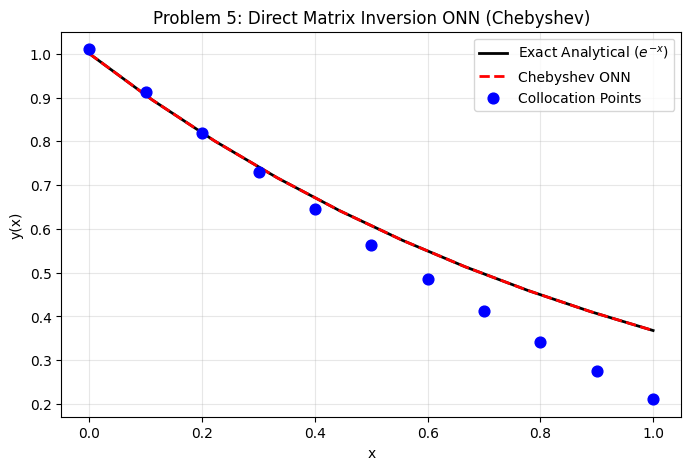

In [2]:
#Problem--5(Chebyshev)(Verified)
import torch
import matplotlib.pyplot as plt

# ==========================================
# 1. Chebyshev Basis Implementation
# ==========================================
def get_Chebyshev_basis(x, n_polys):
    """
    Generates Chebyshev polynomials T_n(x) and their derivatives T'_n(x)
    using standard recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    T = torch.zeros(num_points, n_polys, dtype=torch.float64)
    T_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> T_0 = 1, T'_0 = 0
    T[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> T_1 = x, T'_1 = 1
        T[:, 1] = x
        T_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
        T[:, n] = 2 * x * T[:, n-1] -  T[:, n-2]
        T_d[:, n] = 2*T[:,n-1]+ 2 * x * T_d[:, n-1]- T_d[:, n-2]

    return T, T_d

# ==========================================
# 2. Problem Setup (Problem 5 Linear NDDE)
# ==========================================
N_POLYS = 12
points_colloc = torch.linspace(0,1,11,  dtype=torch.float64)

# Initialize Square System (3 equations, 3 unknowns)
A = torch.zeros(12, N_POLYS, dtype=torch.float64)
b = torch.zeros(12, 1, dtype=torch.float64)

# --- Row 0: Initial Condition y(0) = 1 ---
T_0, _ = get_Chebyshev_basis(torch.tensor([0.0], dtype=torch.float64), N_POLYS)
A[0, :] = T_0
b[0, 0] = 1.0

# --- Rows 1-2: ODE Constraints at Collocation Points ---
for i, x_val in enumerate(points_colloc):
    x = torch.tensor([x_val], dtype=torch.float64)

    # 1. Compute delayed argument
    delay_x = 0.50 * x

    # 2. Evaluate basis at current and delayed arguments
    T_x, Td_x = get_Chebyshev_basis(x, N_POLYS)
    T_delay, Td_delay = get_Chebyshev_basis(delay_x, N_POLYS)

    # 3. Construct LHS (Coefficients for w_n)
    # Re-arranged NDDE: y'(x) - 0.50y'(0.50x) - 0.50y(0.50x) + y(x) = 0
    coeffs = Td_x - 0.50 * Td_delay - 0.50 * T_delay + T_x
    A[i+1, :] = coeffs

    # 4. Construct RHS
    # The right hand side of the equation is exactly 0
    rhs = 0.0
    b[i+1, 0] = rhs

# ==========================================
# 3. Solve for Weights (Direct Matrix Inversion)
# ==========================================
# Using torch.linalg.solve for exact analytical weights on the perfectly determined square matrix

weights = torch.linalg.solve(A, b)

print("--- Discovered Chebyshev Weights ---")
print(f"w0: {weights[0].item():.6f} (Theoretical derived: 1.3158)")
print(f"w1: {weights[1].item():.6f} (Theoretical derived: -1.0000)")
print(f"w2: {weights[2].item():.6f} (Theoretical derived: 0.3158)")

# ==========================================
# 4. Evaluate Solution and Relative Error
# ==========================================
print("\n--- Solution Evaluation (11 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (e^-x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 10, dtype=torch.float64)
T_eval, _ = get_Chebyshev_basis(x_eval, N_POLYS)

# Calculate approximate and exact solutions
y_approx = (T_eval @ weights).flatten()
y_exact = torch.exp(-x_eval)

rel_errors = torch.abs(y_approx - y_exact) / torch.abs(y_exact)

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    error_val = rel_errors[i].item()

    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {error_val:<15.4e}")

# ==========================================
# Calculate and Print Maximum Errors
# ==========================================

# 1. Calculate Maximum Absolute Error
abs_errors = torch.abs(y_approx - y_exact)
max_abs_err = torch.max(abs_errors).item()

# 2. Calculate Maximum Relative Error (safely handling division by zero)
rel_errors = torch.zeros_like(x_eval)
for i in range(len(x_eval)):
    if y_exact[i] == 0.0:
        rel_errors[i] = abs_errors[i]  # Fallback to absolute error if exact is 0
    else:
        rel_errors[i] = abs_errors[i] / torch.abs(y_exact[i])

max_rel_err = torch.max(rel_errors).item()

# 3. Print Results
print("\n--- Error Summary ---")
print(f"Maximum Absolute Error: {max_abs_err:.4e}")
print(f"Maximum Relative Error: {max_rel_err:.4e}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($e^{-x}$)')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label='Chebyshev ONN ')
plt.scatter(points_colloc.numpy(), (get_prob_hermite_basis(points_colloc, N_POLYS)[0] @ weights).flatten().numpy(),
            color='blue', zorder=5, s=60, label='Collocation Points')
plt.title("Problem 5: Direct Matrix Inversion ONN (Chebyshev)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Discovered Chebyshev Weights ---
w0: 1.175201 (Theoretical derived: 1.3158)
w1: -1.103638 (Theoretical derived: -1.0000)
w2: 0.357814 (Theoretical derived: 0.3158)

--- Solution Evaluation (11 Test Points) ---
x     | y_approx     | y_exact (e^-x)  | Relative Error 
-------------------------------------------------------
0.000 | 0.827253     | 1.000000        | 1.7275e-01     
0.111 | 0.735034     | 0.894839        | 1.7859e-01     
0.222 | 0.656569     | 0.800737        | 1.8004e-01     
0.333 | 0.590090     | 0.716531        | 1.7646e-01     
0.444 | 0.534041     | 0.641180        | 1.6710e-01     
0.556 | 0.487055     | 0.573753        | 1.5111e-01     
0.667 | 0.447934     | 0.513417        | 1.2754e-01     
0.778 | 0.415627     | 0.459426        | 9.5334e-02     
0.889 | 0.389211     | 0.411112        | 5.3273e-02     
1.000 | 0.367879     | 0.367879        | 1.5089e-14     

--- Error Summary ---
Maximum Absolute Error: 1.7275e-01
Maximum Relative Error: 1.8004e-01


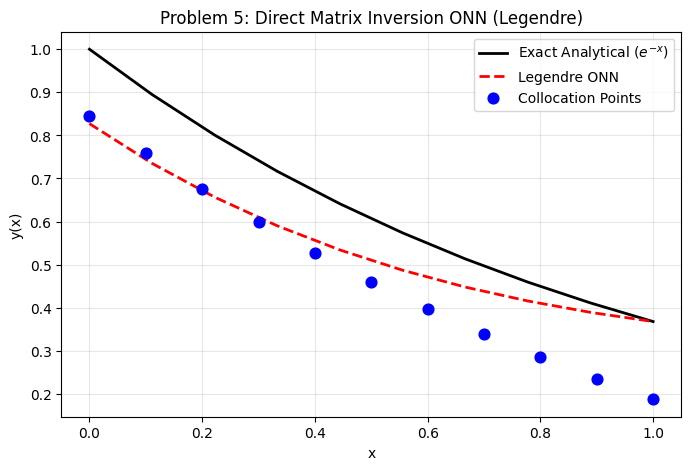

In [3]:
#Problem--5(Legendre)(Verified)
import torch
import matplotlib.pyplot as plt

# ==========================================
# 1. Legendre Basis Implementation
# ==========================================
def get_Legendre_basis(x, n_polys):
    """
    Generates Legendre polynomials T_n(x) and their derivatives T'_n(x)
    using standard recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    T = torch.zeros(num_points, n_polys, dtype=torch.float64)
    T_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> T_0 = 1, T'_0 = 0
    T[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> T_1 = x, T'_1 = 1
        T[:, 1] = x
        T_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
        T[:, n] = ( (2*n-1)*x*T[:,n-1]-(n-1)*T[:,n-2] ) / n
        T_d[:, n] = (  (2*n-1)*(T[:,n-1] +x*T_d[:,n-1]) -(n-1)*T_d[:,n-2])/n


    return T, T_d

# ==========================================
# 2. Problem Setup (Problem 5 Linear NDDE)
# ==========================================
N_POLYS = 12
points_colloc = torch.linspace(0,1,11,  dtype=torch.float64)

# Initialize Square System (3 equations, 3 unknowns)
A = torch.zeros(12, N_POLYS, dtype=torch.float64)
b = torch.zeros(12, 1, dtype=torch.float64)

# --- Row 0: Initial Condition y(0) = 1 ---
T_0, _ = get_Legendre_basis(torch.tensor([0.0], dtype=torch.float64), N_POLYS)
A[0, :] = T_0
b[0, 0] = 1.0

# --- Rows 1-2: ODE Constraints at Collocation Points ---
for i, x_val in enumerate(points_colloc):
    x = torch.tensor([x_val], dtype=torch.float64)

    # 1. Compute delayed argument
    delay_x = 0.50 * x

    # 2. Evaluate basis at current and delayed arguments
    T_x, Td_x = get_Legendre_basis(x, N_POLYS)
    T_delay, Td_delay = get_Legendre_basis(delay_x, N_POLYS)

    # 3. Construct LHS (Coefficients for w_n)
    # Re-arranged NDDE: y'(x) - 0.50y'(0.50x) - 0.50y(0.50x) + y(x) = 0
    coeffs = Td_x - 0.50 * Td_delay - 0.50 * T_delay + T_x
    A[i+1, :] = coeffs

    # 4. Construct RHS
    # The right hand side of the equation is exactly 0
    rhs = 0.0
    b[i+1, 0] = rhs

# ==========================================
# 3. Solve for Weights (Direct Matrix Inversion)
# ==========================================
# Using torch.linalg.solve for exact analytical weights on the perfectly determined square matrix
#print(A)
#print(b)
weights = torch.linalg.solve(A, b)

print("--- Discovered Chebyshev Weights ---")
print(f"w0: {weights[0].item():.6f} (Theoretical derived: 1.3158)")
print(f"w1: {weights[1].item():.6f} (Theoretical derived: -1.0000)")
print(f"w2: {weights[2].item():.6f} (Theoretical derived: 0.3158)")

# ==========================================
# 4. Evaluate Solution and Relative Error
# ==========================================
print("\n--- Solution Evaluation (11 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (e^-x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 10, dtype=torch.float64)
T_eval, _ = get_Chebyshev_basis(x_eval, N_POLYS)

# Calculate approximate and exact solutions
y_approx = (T_eval @ weights).flatten()
y_exact = torch.exp(-x_eval)

rel_errors = torch.abs(y_approx - y_exact) / torch.abs(y_exact)

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    error_val = rel_errors[i].item()

    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {error_val:<15.4e}")

# ==========================================
# Calculate and Print Maximum Errors
# ==========================================

# 1. Calculate Maximum Absolute Error
abs_errors = torch.abs(y_approx - y_exact)
max_abs_err = torch.max(abs_errors).item()

# 2. Calculate Maximum Relative Error (safely handling division by zero)
rel_errors = torch.zeros_like(x_eval)
for i in range(len(x_eval)):
    if y_exact[i] == 0.0:
        rel_errors[i] = abs_errors[i]  # Fallback to absolute error if exact is 0
    else:
        rel_errors[i] = abs_errors[i] / torch.abs(y_exact[i])

max_rel_err = torch.max(rel_errors).item()

# 3. Print Results
print("\n--- Error Summary ---")
print(f"Maximum Absolute Error: {max_abs_err:.4e}")
print(f"Maximum Relative Error: {max_rel_err:.4e}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($e^{-x}$)')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label='Legendre ONN ')
plt.scatter(points_colloc.numpy(), (get_prob_hermite_basis(points_colloc, N_POLYS)[0] @ weights).flatten().numpy(),
            color='blue', zorder=5, s=60, label='Collocation Points')
plt.title("Problem 5: Direct Matrix Inversion ONN (Legendre)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()